<a href="https://colab.research.google.com/github/Ishan995/monte_carlo/blob/main/Monte_Carlo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Inventory Safety Stock Optimization via Monte Carlo Simulation

## 1. The Problem: Why Simple Math Fails
In supply chain management, the **Reorder Point (ROP)** is the inventory level at which we place a new order.

Traditional formulas often use: `ROP = (Average Daily Demand × Lead Time)`.

**The flaw:** This assumes demand and lead time are constant. If demand is higher than average or the shipment is late, you hit a **stockout**. To prevent this, we add **Safety Stock**. While standard formulas exist (using Z-scores), they assume a perfect Normal distribution. **Monte Carlo simulation** allows us to model any distribution and capture the complex interaction between demand volatility and lead-time uncertainty.

Daily Demand Statistics:
- Mean: 22323.94
- Std Dev: 5784.40
- Coefficient of Variation: 0.26


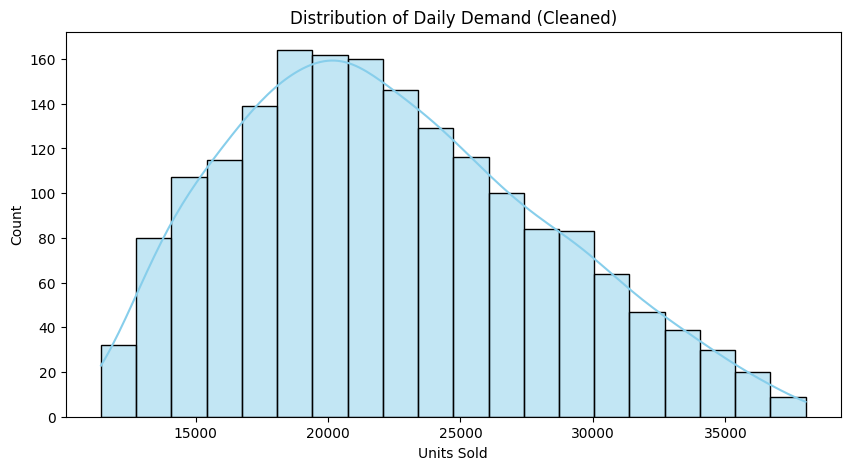

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/retail_sales.csv')

# Clean the data: handle malformed dates and missing values
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date', 'sales'])

# Calculate daily demand statistics
daily_demand = df.groupby('date')['sales'].sum()

mean_demand = daily_demand.mean()
std_demand = daily_demand.std()

print(f"Daily Demand Statistics:")
print(f"- Mean: {mean_demand:.2f}")
print(f"- Std Dev: {std_demand:.2f}")
print(f"- Coefficient of Variation: {std_demand/mean_demand:.2f}")

# Visualize the distribution
plt.figure(figsize=(10, 5))
sns.histplot(daily_demand, kde=True, color='skyblue')
plt.title('Distribution of Daily Demand (Cleaned)')
plt.xlabel('Units Sold')
plt.show()

## 2. Setting Simulation Parameters
Now we define our supply chain constraints. In a real-world scenario:
- **Lead Time:** The time between ordering and receiving goods (often variable).
- **Holding Cost:** The cost of keeping one unit in the warehouse (capital, space, insurance).
- **Stockout Cost:** The 'hidden' cost of a lost sale (lost margin + loss of customer goodwill).

In [2]:
# Simulation Constants
LEAD_TIME_MEAN = 7  # Average days to receive an order
LEAD_TIME_STD = 1.5 # Uncertainty in delivery

HOLDING_COST_PER_UNIT = 0.50  # Cost per unit per period
STOCKOUT_COST_PER_UNIT = 15.0 # High penalty for losing a customer

TARGET_SERVICE_LEVEL = 0.95 # We want to fulfill 95% of orders

NUM_TRIALS = 10000 # Number of Monte Carlo iterations

## 3. Monte Carlo Simulation: Demand During Lead Time (DDLT)
We perform the simulation by:
1. Sampling a **Lead Time** from a Normal distribution.
2. For each day in that lead time, sampling **Daily Demand**.
3. Calculating total demand for that period.
4. Repeating this 10,000 times to see the range of possible outcomes.

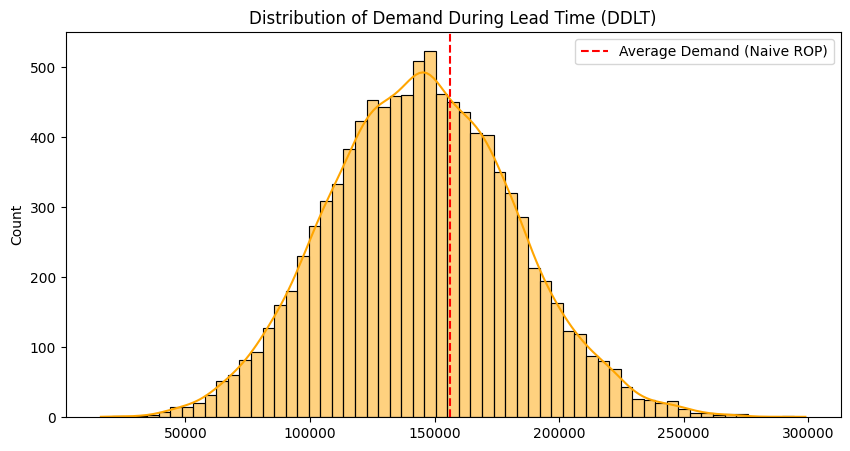

In [4]:
def run_monte_carlo(num_trials, mean_d, std_d, mean_lt, std_lt):
    ddlt_results = []
    for _ in range(num_trials):
        # Sample lead time (must be at least 1 day)
        simulated_lt = max(1, int(np.random.normal(mean_lt, std_lt)))
        # Sample daily demand for each day in the lead time
        simulated_demand = np.random.normal(mean_d, std_d, simulated_lt).sum()
        ddlt_results.append(max(0, simulated_demand))
    return np.array(ddlt_results)

# Run simulation
ddlt_sim = run_monte_carlo(NUM_TRIALS, mean_demand, std_demand, LEAD_TIME_MEAN, LEAD_TIME_STD)

# Visualize DDLT
plt.figure(figsize=(10, 5))
sns.histplot(ddlt_sim, kde=True, color='orange')
plt.axvline(mean_demand * LEAD_TIME_MEAN, color='red', linestyle='--', label='Average Demand (Naive ROP)')
plt.title('Distribution of Demand During Lead Time (DDLT)')
plt.legend()
plt.show()

## 4. Optimization: Finding the 'Sweet Spot'
We will now iterate through potential safety stock levels.
- **Service Level**: What % of the time did we NOT stock out?
- **Total Cost**: Holding Cost + Expected Stockout Cost.

The goal is to find the safety stock that minimizes total cost while ideally maintaining our 95% service level target.

In [5]:
results = []
# Test safety stock levels from 0 to 3 standard deviations of DDLT
ss_range = np.linspace(0, ddlt_sim.std() * 3, 50)

expected_lt_demand = mean_demand * LEAD_TIME_MEAN

for ss in ss_range:
    reorder_point = expected_lt_demand + ss
    stockouts = ddlt_sim[ddlt_sim > reorder_point]
    num_stockouts = len(stockouts)

    service_level = 1 - (num_stockouts / NUM_TRIALS)

    # Costs
    holding_cost = ss * HOLDING_COST_PER_UNIT
    # Expected stockout cost = (Avg units missed) * Cost * Probability of occurring
    avg_missed_units = (stockouts - reorder_point).mean() if num_stockouts > 0 else 0
    stockout_cost = avg_missed_units * STOCKOUT_COST_PER_UNIT * (num_stockouts / NUM_TRIALS)

    total_cost = holding_cost + stockout_cost

    results.append({
        'safety_stock': ss,
        'service_level': service_level,
        'total_cost': total_cost,
        'holding_cost': holding_cost,
        'stockout_cost': stockout_cost
    })

res_df = pd.DataFrame(results)
optimal_row = res_df.loc[res_df['total_cost'].idxmin()]

print(f"Optimal Safety Stock: {optimal_row['safety_stock']:.2f} units")
print(f"Resulting Service Level: {optimal_row['service_level']*100:.2f}%")
print(f"Minimum Expected Cost: ${optimal_row['total_cost']:.2f}")

Optimal Safety Stock: 59084.23 units
Resulting Service Level: 96.75%
Minimum Expected Cost: $37210.66


## 5. Sensitivity Analysis: Stress-Testing the Model
In an interview, you should explain: 'What happens if our suppliers become less reliable?'
We will simulate an increase in Lead Time volatility and observe the impact on the Cost/Service Level tradeoff.

In [6]:
# Simulate a 'High Uncertainty' scenario (Lead Time Std Dev doubles)
ddlt_high_vol = run_monte_carlo(NUM_TRIALS, mean_demand, std_demand, LEAD_TIME_MEAN, LEAD_TIME_STD * 2)

# Calculate metrics for the SAME safety stock we just picked
reorder_point_opt = (mean_demand * LEAD_TIME_MEAN) + optimal_row['safety_stock']
stockouts_hv = ddlt_high_vol[ddlt_high_vol > reorder_point_opt]
service_level_hv = 1 - (len(stockouts_hv) / NUM_TRIALS)

print(f"--- Stress Test Results ---")
print(f"Original Service Level: {optimal_row['service_level']*100:.2f}%")
print(f"Service Level if Lead Time Volatility doubles: {service_level_hv*100:.2f}%")
print(f"Conclusion: Increased supply chain uncertainty requires an additional buffer to maintain the same service.")

--- Stress Test Results ---
Original Service Level: 96.75%
Service Level if Lead Time Volatility doubles: 85.31%
Conclusion: Increased supply chain uncertainty requires an additional buffer to maintain the same service.


## 6. Monte Carlo vs. Naive Approach
Finally, let's quantify the ROI of your data science work. We compare the **Naive ROP** (no safety stock) vs. our **Optimized ROP**.

--- Business Impact ---
Naive Approach Service Level: 62.19%
Optimized Approach Service Level: 96.75%
Cost Savings per period: $111911.11


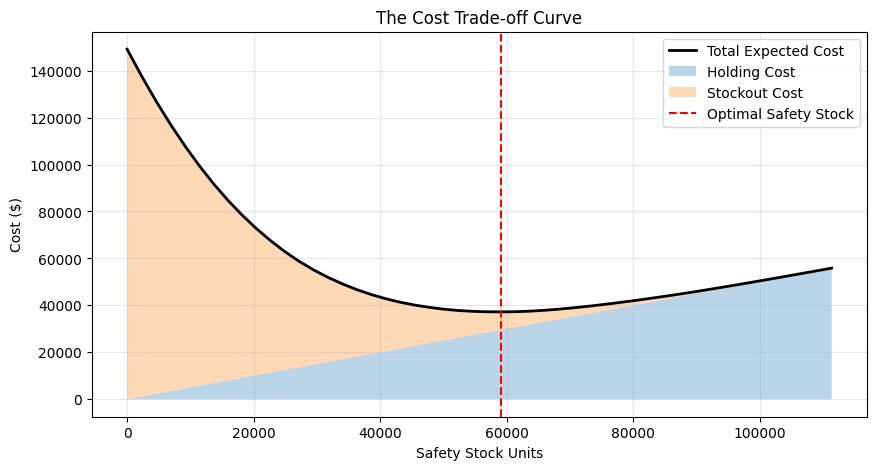

In [7]:
# Naive approach: ROP = Mean Demand during Lead Time
naive_rop = mean_demand * LEAD_TIME_MEAN
naive_stockouts = ddlt_sim[ddlt_sim > naive_rop]
naive_service_level = 1 - (len(naive_stockouts) / NUM_TRIALS)
naive_avg_missed = (naive_stockouts - naive_rop).mean()
naive_cost = naive_avg_missed * STOCKOUT_COST_PER_UNIT * (len(naive_stockouts) / NUM_TRIALS)

print(f"--- Business Impact ---")
print(f"Naive Approach Service Level: {naive_service_level*100:.2f}%")
print(f"Optimized Approach Service Level: {optimal_row['service_level']*100:.2f}%")
print(f"Cost Savings per period: ${naive_cost - optimal_row['total_cost']:.2f}")

# Plotting the cost curve
plt.figure(figsize=(10, 5))
plt.plot(res_df['safety_stock'], res_df['total_cost'], label='Total Expected Cost', color='black', lw=2)
plt.fill_between(res_df['safety_stock'], res_df['holding_cost'], alpha=0.3, label='Holding Cost')
plt.fill_between(res_df['safety_stock'], res_df['holding_cost'], res_df['total_cost'], alpha=0.3, label='Stockout Cost')
plt.axvline(optimal_row['safety_stock'], color='red', linestyle='--', label='Optimal Safety Stock')
plt.title('The Cost Trade-off Curve')
plt.xlabel('Safety Stock Units')
plt.ylabel('Cost ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Summary for your Portfolio/Interview
1. **Why Monte Carlo?** Unlike the standard Normal distribution formula, this captures the non-linear interaction between demand peaks and late shipments.
2. **The Connection to Forecasting:** Your LightGBM model predicts the `mean_demand`. This project takes that prediction and adds the 'risk layer' necessary for actual business operations.
3. **Limitations:** The simulation assumes the future distribution mirrors the past. In a real world 'Black Swan' event (like 2020), historical variance is insufficient, requiring manual overrides or scenario-based stress tests.